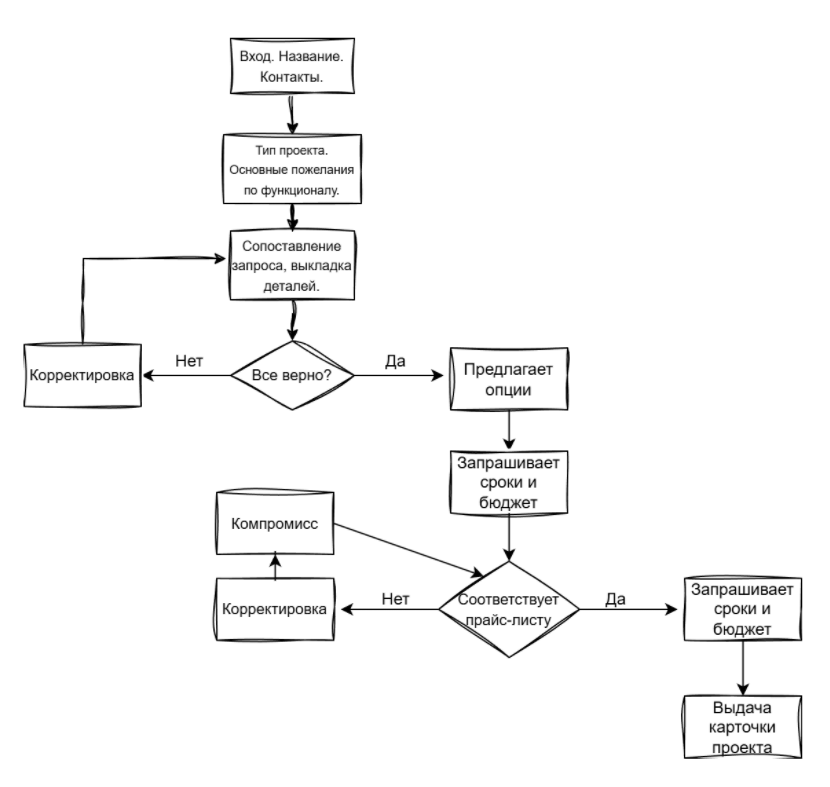

In [11]:
from langchain_gigachat.chat_models import GigaChat
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
import os
load_dotenv()

CRED = os.getenv("GIGACHAT_CRED")

llm = GigaChat(
        credentials=CRED,
        scope="GIGACHAT_API_PERS",
        model="GigaChat-2",
        verify_ssl_certs=False,
        temperature=0.2
    )

In [2]:
from pydantic import BaseModel, Field
from typing import List, Literal, TypedDict

# Модель заказчика
class Customer(BaseModel):
    name: str = Field(
        description="Имя заказчика"
    )
    email: str = Field(
        description="Электронная почка заказчика"
    )
    phone: str = Field(
        description="Номер телефона заказчика"
    )

class Project(TypedDict):
    customer: Customer

project_types = ["Создание корпоративного сайта", "Создание интернет-магазина", "Создание простого лендинга"]

In [3]:
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage, AIMessage

class SystemState(TypedDict):
    messages: List[BaseMessage]
    current_user_input: str
    project: Project

In [4]:
def entry_node(state: SystemState) -> dict:
    """Входной узел"""
    user_input = input().strip()

    try:
        messages = state['messages'] + [HumanMessage(content=f"Необходимо поприветствовать пользователя и рассказать о спектре услуг. Проекты, которые возможно выполнить: {project_types}. Далее спросить, какой именно проект нужен пользователю и его контактные данные, включающие имя, email и телефонный номер.")]

        response = llm.invoke(messages)
        ai_response = response.content

        print(ai_response)

        new_messages = messages + [AIMessage(content=ai_response)]
        return {"messages": new_messages}
    
    except Exception as e:
        messages = state["messages"] + [
            HumanMessage(content=user_input),
            AIMessage(content="Извините, произошла ошибка при обработке вашего вопроса.")
        ]
        
        return {"messages": messages}

In [5]:
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import PromptTemplate

customer_parser = JsonOutputParser(pydantic_object=Customer)
customer_prompt = PromptTemplate(
    template="""Вычлени из сообщения необходимую информацию о пользователе.

Сообщение: {user_input}

{format_instructions}

Верни ТОЛЬКО JSON!""",
    input_variables=["user_input"],
    partial_variables={"format_instructions": customer_parser.get_format_instructions()}
)

def parse_customer_node(state: SystemState) -> dict:
    user_input = input().strip()

    try:
        parser_chain = customer_prompt | llm | customer_parser
        result = parser_chain.invoke({"user_input": user_input})

        customer_name = result["name"]
        customer_email = result["email"]
        customer_phone = result["phone"]

        return {"project": {
            "customer": {
                "name": customer_name,
                "email": customer_email,
                "phone": customer_phone,
            }
        }}
    
    except Exception as e:
        print(f"Ошибка классификации: {e}")

        return {"project": {
            "customer": {
                "name": "None",
                "email": "None",
                "phone": "None",
            }
        }}

In [6]:
def final_node(state: SystemState) -> dict:
    print(state['project'])

In [7]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(SystemState)

graph.add_node("entry", entry_node)
graph.add_node("parse_customer", parse_customer_node)
graph.add_node("final", final_node)

def route_after_input(state: SystemState) -> str:
    """Маршрутизация после ввода пользователя"""
    if state.get("current_user_input"):
        return "parse_customer"
    
    return "entry"

In [8]:
graph.add_edge(START, "entry")
graph.add_edge("entry", "parse_customer")
graph.add_edge("parse_customer", "final")
graph.add_edge("final", END)

In [10]:
app = graph.compile()
initial_state = {
    "messages": [
        SystemMessage(content="Ты дружелюбный помощник. Отвечай коротко и по делу на вопросы пользователя.")
    ],
    "current_user_input": "",
    "project": Project()
}

app.invoke(initial_state)

Здравствуйте! Мы предлагаем создание корпоративного сайта, интернет-магазина или простого лендинга. Какой проект Вам интересен? Не могли бы Вы также предоставить Ваше имя, email и телефонный номер для связи?
{'customer': {'name': 'Арсений', 'email': 'sdsdkj@mail.com', 'phone': '43-31-32'}}


{'messages': [SystemMessage(content='Ты дружелюбный помощник. Отвечай коротко и по делу на вопросы пользователя.', additional_kwargs={}, response_metadata={}),
  HumanMessage(content="Необходимо поприветствовать пользователя и рассказать о спектре услуг. Проекты, которые возможно выполнить: ['Создание корпоративного сайта', 'Создание интернет-магазина', 'Создание простого лендинга']. Далее спросить, какой именно проект нужен пользователю и его контактные данные, включающие имя, email и телефонный номер.", additional_kwargs={}, response_metadata={}),
  AIMessage(content='Здравствуйте! Мы предлагаем создание корпоративного сайта, интернет-магазина или простого лендинга. Какой проект Вам интересен? Не могли бы Вы также предоставить Ваше имя, email и телефонный номер для связи?', additional_kwargs={}, response_metadata={})],
 'current_user_input': '',
 'project': {'customer': {'name': 'Арсений',
   'email': 'sdsdkj@mail.com',
   'phone': '43-31-32'}}}